<a href="https://colab.research.google.com/github/JulmiBhaiPM/Monocular-distance-estimation/blob/main/PRP_Mark_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#2
import pandas as pd

meta = pd.read_csv("/content/drive/MyDrive/PRP_Project/metadata.csv")
ann = pd.read_csv("/content/drive/MyDrive/PRP_Project/annotations.csv")

In [ ]:
#3
import pandas as pd
import numpy as np

meta = pd.read_csv("/content/drive/MyDrive/PRP_Project/metadata.csv")
ann = pd.read_csv("/content/drive/MyDrive/PRP_Project/annotations.csv")


if 'image_name' in ann.columns:
    ann_clean = ann[['image_name','bbox_height']].rename(columns={'image_name':'filename','bbox_height':'pixel_height'})
elif 'filename' in ann.columns and 'bbox_height' in ann.columns:
    ann_clean = ann[['filename','bbox_height']].rename(columns={'bbox_height':'pixel_height'})
else:
    raise ValueError("Unexpected annotation columns: " + str(list(ann.columns)))

meta['filename'] = meta['filename'].astype(str)
ann_clean['filename'] = ann_clean['filename'].astype(str)

df = meta.merge(ann_clean, on='filename')
df['distance_m'] = df['distance_m'].astype(float)
df = df.sort_values('distance_m').reset_index(drop=True)

print("Merged dataframe (top rows):")
display(df)

Merged dataframe (top rows):


,filename,distance_m,angle,pixel_height
0,center_1m.heic,1.0,center,2192
1,left_1m.heic,1.0,left,2246
2,right_1m.heic,1.0,right,2076
3,center_2m.heic,2.0,center,1282
4,left_2m.heic,2.0,left,1194
5,right_2m.heic,2.0,right,1121
6,center_4m.heic,4.0,center,683
7,left_4m.heic,4.0,left,691
8,right_4m.heic,4.0,right,660
9,center_8m.heic,8.0,center,369


In [ ]:
#4
df['inv_dist'] = 1.0 / df['distance_m']
print(df[['filename','distance_m','inv_dist','pixel_height','angle']].to_string(index=False))

print("\nPixel height stats:")
display(df['pixel_height'].describe())

       filename  distance_m  inv_dist  pixel_height  angle
 center_1m.heic         1.0  1.000000          2192 center
   left_1m.heic         1.0  1.000000          2246   left
  right_1m.heic         1.0  1.000000          2076  right
 center_2m.heic         2.0  0.500000          1282 center
   left_2m.heic         2.0  0.500000          1194   left
  right_2m.heic         2.0  0.500000          1121  right
 center_4m.heic         4.0  0.250000           683 center
   left_4m.heic         4.0  0.250000           691   left
  right_4m.heic         4.0  0.250000           660  right
 center_8m.heic         8.0  0.125000           369 center
   left_8m.heic         8.0  0.125000           367   left
  right_8m.heic         8.0  0.125000           359  right
center_12m.heic        12.0  0.083333           254 center
  left_12m.heic        12.0  0.083333           256   left
 right_12m.heic        12.0  0.083333           253  right
center_20m.heic        20.0  0.050000           155 cent

,pixel_height
count,18.000000
mean,803.777778
std,723.607999
min,153.000000
25%,254.500000
50%,514.500000
75%,1175.750000
max,2246.000000


In [ ]:
#5
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[['inv_dist']].values
y = df['pixel_height'].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

k = model.coef_[0]
b = model.intercept_

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Model: pixel_height = k*(1/distance) + b")
print(f"k = {k:.4f}")
print(f"b = {b:.4f}")
print(f"RMSE = {rmse:.3f} pixels")
print(f"MAE  = {mae:.3f} pixels")
print(f"R^2  = {r2:.3f}")

df['pred_pixel'] = y_pred
df['residual'] = df['pixel_height'] - df['pred_pixel']

display(df[['filename','distance_m','pixel_height','pred_pixel','residual']])

Model: pixel_height = k*(1/distance) + b
k = 2105.1767
b = 99.1284
RMSE = 55.530 pixels
MAE  = 42.605 pixels
R^2  = 0.994


,filename,distance_m,pixel_height,pred_pixel,residual
0,center_1m.heic,1.0,2192,2204.305024,-12.305024
1,left_1m.heic,1.0,2246,2204.305024,41.694976
2,right_1m.heic,1.0,2076,2204.305024,-128.305024
3,center_2m.heic,2.0,1282,1151.716697,130.283303
4,left_2m.heic,2.0,1194,1151.716697,42.283303
5,right_2m.heic,2.0,1121,1151.716697,-30.716697
6,center_4m.heic,4.0,683,625.422533,57.577467
7,left_4m.heic,4.0,691,625.422533,65.577467
8,right_4m.heic,4.0,660,625.422533,34.577467
9,center_8m.heic,8.0,369,362.275452,6.724548


In [ ]:
#6
new_distances = np.array([25.0, 30.0, 35.0])
inv_new = 1.0 / new_distances.reshape(-1,1)
preds = model.predict(inv_new)

for d,p in zip(new_distances, preds):
    print(f"Distance {d} m -> predicted pixel height = {p:.2f} px")

nboots = 2000
boot_preds = np.zeros((nboots, len(new_distances)))
rng = np.random.RandomState(0)
X_full = X; y_full = y
for i in range(nboots):
    idx = rng.randint(0, len(X_full), size=len(X_full))
    mb = LinearRegression().fit(X_full[idx], y_full[idx])
    boot_preds[i,:] = mb.predict(inv_new)

lower = np.percentile(boot_preds, 2.5, axis=0)
upper = np.percentile(boot_preds, 97.5, axis=0)
for d,low,mid,high in zip(new_distances, preds, lower, upper):
    print(f"{d} m: pred = {mid:.2f} px  95% CI = [{low:.2f}, {high:.2f}]")

Distance 25.0 m -> predicted pixel height = 183.34 px
Distance 30.0 m -> predicted pixel height = 169.30 px
Distance 35.0 m -> predicted pixel height = 159.28 px
25.0 m: pred = 155.35 px  95% CI = [183.34, 213.99]
30.0 m: pred = 140.05 px  95% CI = [169.30, 200.31]
35.0 m: pred = 129.54 px  95% CI = [159.28, 190.53]


Model: pixel_height = k*(1/distance) + b
k = 2105.18, b = 99.13
R² = 0.9938
RMSE = 55.53 px
MAE = 42.60 px


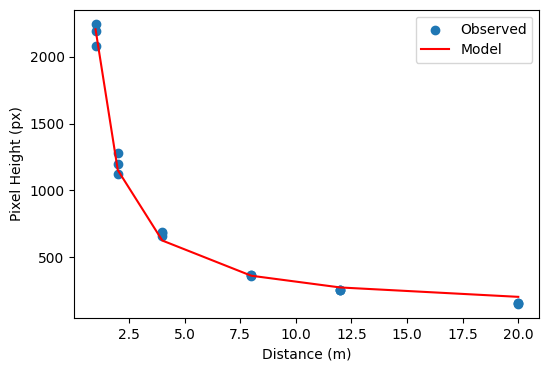


Demo predictions:
Distance 5 m → 520.16 px
Distance 10 m → 309.65 px
Distance 15 m → 239.47 px
Distance 25 m → 183.34 px
Distance 30 m → 169.30 px


In [ ]:
#7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = (1 / df['distance_m']).values.reshape(-1, 1)
y = df['pixel_height'].values

model = LinearRegression()
model.fit(X, y)

k = model.coef_[0]
b = model.intercept_

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("Model: pixel_height = k*(1/distance) + b")
print(f"k = {k:.2f}, b = {b:.2f}")
print(f"R² = {r2:.4f}")
print(f"RMSE = {rmse:.2f} px")
print(f"MAE = {mae:.2f} px")

plt.figure(figsize=(6,4))
plt.scatter(df['distance_m'], df['pixel_height'], label="Observed")
plt.plot(df['distance_m'], y_pred, color='red', label="Model")
plt.xlabel("Distance (m)")
plt.ylabel("Pixel Height (px)")
plt.legend()
plt.show()

def predict_pixel_height(distance_m):
    return k * (1/distance_m) + b

print("\nDemo predictions:")
for d in [5, 10, 15, 25, 30]:
    print(f"Distance {d} m → {predict_pixel_height(d):.2f} px")

In [ ]:
#8
def predict_pixel_height(distance_m):
    return k * (1/distance_m) + b

for d in [2.5, 6, 9, 14, 18, 25, 40, 60]:
    print(f"Distance: {d} m → Predicted pixel height: {predict_pixel_height(d):.2f} px")

Distance: 2.5 m → Predicted pixel height: 941.20 px
Distance: 6 m → Predicted pixel height: 449.99 px
Distance: 9 m → Predicted pixel height: 333.04 px
Distance: 14 m → Predicted pixel height: 249.50 px
Distance: 18 m → Predicted pixel height: 216.08 px
Distance: 25 m → Predicted pixel height: 183.34 px
Distance: 40 m → Predicted pixel height: 151.76 px
Distance: 60 m → Predicted pixel height: 134.21 px


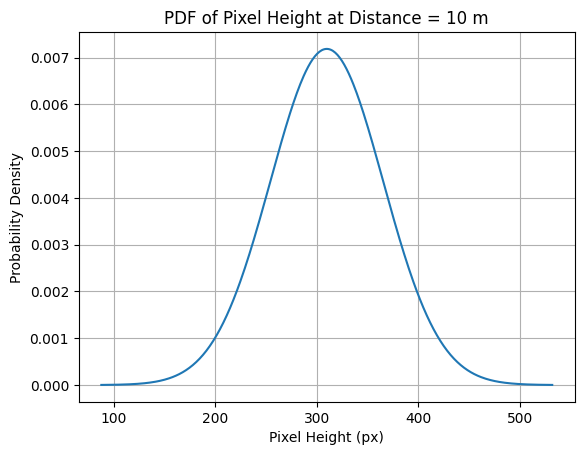

In [ ]:
#9
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

residuals = y - y_pred
sigma = np.std(residuals)

d_demo = 10  # meters
mu = predict_pixel_height(d_demo)

y_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)


pdf_vals = norm.pdf(y_vals, mu, sigma)

plt.figure()
plt.plot(y_vals, pdf_vals)
plt.xlabel("Pixel Height (px)")
plt.ylabel("Probability Density")
plt.title(f"PDF of Pixel Height at Distance = {d_demo} m")
plt.grid(True)
plt.show()

In [ ]:
#10
from scipy.stats import norm

log_likelihood = np.sum(
    norm.logpdf(y, loc=y_pred, scale=sigma)
)

print(f"Log-Likelihood of observed data: {log_likelihood:.2f}")

Log-Likelihood of observed data: -97.85
